In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [2]:
import pandas as pd
import glob
import os

station_dfs = []
for case in ['train', 'test']:

    # Step 1: Load all Excel files
    file_paths = glob.glob(f'data_leaks/benchmark/{case}_guan/*.xlsx')

    for path in file_paths:
        df = pd.read_excel(path)

        # Convert time to datetime
        df['timestamp'] = pd.to_datetime(df['time'])

        # Get station_id (assume all rows in file have same value)
        station_id = df['station_id'].iloc[0]

        # Create a new column: available = free / total
        df[f'{station_id}'] = df['free'] / df['total']

        # Keep only relevant columns
        df = df[['timestamp', f'{station_id}']]

        station_dfs.append(df)

# Step 2: Combine all into one DataFrame (time index, station_id columns)
df_guan = pd.concat(station_dfs, axis=1)
df_guan = df_guan.loc[:, ~df_guan.columns.duplicated()]

df_guan['timestamp'] = pd.to_datetime(df_guan['timestamp'])

# Subtract the first timestamp and convert to seconds
df_guan['timestamp'] = (df_guan['timestamp'] - df_guan['timestamp'].iloc[0]).dt.total_seconds().astype(int)


df_guan.head()

,timestamp,26323,26898,36284,37402,38764,40574,40575,42148,42149,...,87579,87581,87587,87588,88842,89086,89449,89450,89451,89453
0,0,0.166667,0.500000,0.550000,0.294118,0.655172,0.409091,0.333333,0.363636,0.555556,...,0.942308,0.614286,0.666667,0.555556,0.452381,0.60,0.7,0.869565,0.551724,0.550
1,300,0.166667,0.384615,0.000000,0.235294,0.448276,0.409091,0.300000,0.409091,0.611111,...,0.903846,0.671429,0.633333,0.416667,0.309524,0.48,0.8,0.804348,0.482759,0.550
2,600,0.166667,0.269231,0.266667,0.205882,0.344828,0.545455,0.300000,0.409091,0.527778,...,0.903846,0.700000,0.633333,0.333333,0.285714,0.44,0.8,0.804348,0.517241,0.525
3,900,0.166667,0.192308,0.316667,0.294118,0.275862,0.500000,0.300000,0.318182,0.444444,...,0.903846,0.728571,0.633333,0.333333,0.238095,0.40,0.7,0.739130,0.448276,0.525
4,1200,0.166667,0.115385,0.216667,0.382353,0.275862,0.454545,0.300000,0.227273,0.333333,...,0.884615,0.742857,0.600000,0.305556,0.238095,0.40,0.6,0.717391,0.413793,0.500


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

def aggregate_series(series, factor):
    """Aggregate a 1D series using mean over chunks of size `factor`."""
    n = len(series)
    trimmed = series[:n - (n % factor)]
    reshaped = trimmed.values.reshape(-1, factor)
    return reshaped.mean(axis=1)

def get_aggregated_columns(df, agg_factor):
    """
    Aggregate all columns in the DataFrame (column-wise time series).
    Returns: dict of {column_name: aggregated_series}
    """
    series_dict = {}
    for col in df.columns:
        if col in ['#', '', 'timestamp']:
            continue
        aggregated = aggregate_series(df[col], agg_factor)
        series_dict[col] = aggregated
    return series_dict

def get_most_similar_series(df, target_col, agg_factor=1, top_n=5):
    """
    Compare target column against all others and return top-N similar.
    """
    series_dict = get_aggregated_columns(df, agg_factor)

    if target_col not in series_dict:
        raise ValueError(f"Target column '{target_col}' not found.")

    all_columns = list(series_dict.keys())
    all_series = np.stack([series_dict[col] for col in all_columns])
    target_index = all_columns.index(target_col)

    target_series = all_series[target_index].reshape(1, -1)
    distances = euclidean_distances(target_series, all_series)[0]
    distances[target_index] = np.inf  # ignore self

    top_indices = np.argsort(distances)[:top_n]
    top_columns = [all_columns[i] for i in top_indices]
    top_distances = distances[top_indices]

    return top_columns, top_distances, series_dict

def plot_similar_columns(df, target_col, similar_cols, agg_factor=None):
    """
    Plot target column and its most similar columns.

    Parameters:
    - df: Original DataFrame with column-wise time series.
    - target_col: Name of the target column (string).
    - similar_cols: List of similar column names (strings).
    - agg_factor: Optional aggregation factor (int or None).
    """
    def maybe_aggregate(series, factor):
        arr = series if isinstance(series, np.ndarray) else series.to_numpy()
        if factor is None:
            return arr
        n = len(arr)
        trimmed = arr[:n - (n % factor)]
        reshaped = trimmed.reshape(-1, factor)
        return reshaped.mean(axis=1)

    # Prepare target series
    target_series = maybe_aggregate(df[target_col], agg_factor)
    x = np.arange(len(target_series))

    plt.figure(figsize=(10, 6))
    plt.plot(x, target_series, label=f"Target: {target_col}", color='black', linewidth=3)

    for i, col in enumerate(similar_cols):
        sim_series = maybe_aggregate(df[col], agg_factor)
        plt.plot(x, sim_series, label=f"Similar {i+1}: {col}", alpha=0.7)

    title_suffix = f"(Aggregated by {agg_factor})" if agg_factor else "(No Aggregation)"
    plt.title(f"Target '{target_col}' and Top {len(similar_cols)} Most Similar Series {title_suffix}")
    plt.xlabel("Time Step" if agg_factor is None else "Aggregated Time Step")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

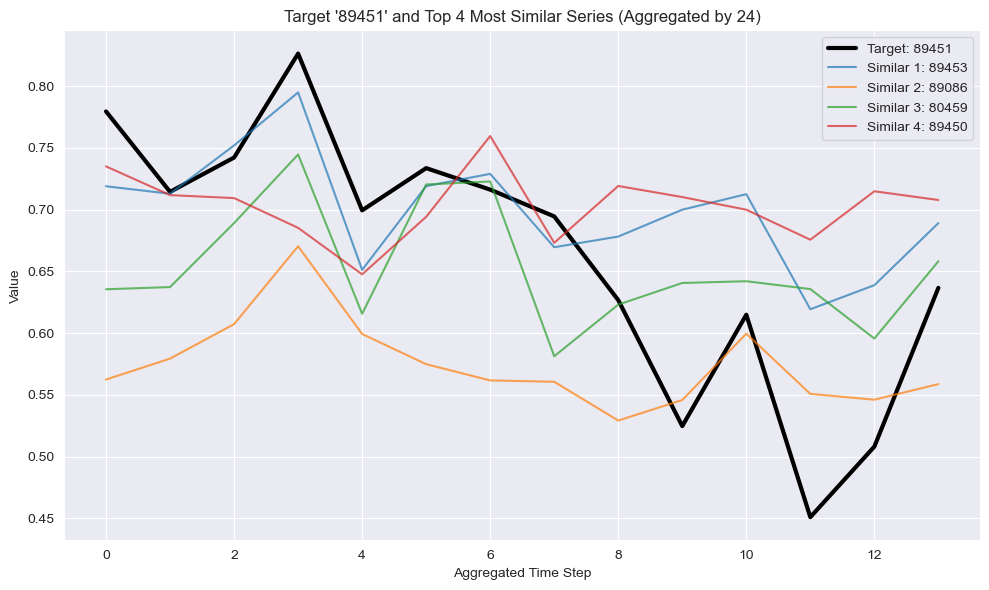

In [44]:
# Use a column name as the target (must be a string)
target_column = "89451"
agg_factor = 24
top_n = 4

# Get most similar columns
similar_cols, distances, series_dict = get_most_similar_series(df_guan, target_column, agg_factor, top_n)

# Plot
plot_similar_columns(series_dict, target_column, similar_cols, agg_factor = 24)

In [50]:
import pandas as pd
import numpy as np

def select_stable_cases(df, timestamp, agg_window=2, threshold=0.05, method='std'):
    """
    Select stable cases around a given timestamp.

    Args:
        df (pd.DataFrame): The full time series data.
        timestamp (float or int): Timestamp to center the window on.
        agg_window (int): Number of rows before and after to include.
        threshold (float): Maximum allowed variation (std or range).
        method (str): 'std' or 'range' for variation check.

    Returns:
        List of case IDs (columns) considered stable.
    """
    # Find closest index to the given timestamp
    idx = (df['timestamp'] - timestamp).abs().idxmin()

    # Define window bounds
    start_idx = max(0, idx - agg_window)
    end_idx = min(len(df), idx + agg_window + 1)

    # Subset the window
    window_df = df.iloc[start_idx:end_idx, 3:]  # skip non-case columns

    stable_cases = []

    for case in window_df.columns:
        values = window_df[case].dropna()

        if method == 'std':
            variation = np.std(values)
        elif method == 'range':
            variation = values.max() - values.min()
        else:
            raise ValueError("Method must be 'std' or 'range'")

        if variation <= threshold:
            stable_cases.append(case)

    return stable_cases

import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

def select_unstable_cases(df, timestamp, agg_window=2, threshold=None, top_n=None, method='std'):
    """
    Select unstable (most variable or drifting) cases around a given timestamp.

    Args:
        df (pd.DataFrame): The full time series data.
        timestamp (float or int): Timestamp to center the window on.
        agg_window (int): Number of rows before and after to include.
        threshold (float, optional): Minimum variation to consider a case unstable.
        top_n (int, optional): Return only the top N most unstable cases.
        method (str): 'std', 'range', or 'mean_diff' for variation check.

    Returns:
        Tuple[List[str], pd.Series]: List of unstable case IDs, and their variation scores.
    """
    # Find closest index to the given timestamp
    idx = (df['timestamp'] - timestamp).abs().idxmin()

    # Define window bounds
    start_idx = max(0, idx - agg_window)
    end_idx = min(len(df), idx + agg_window + 1)

    # Subset the window (only case columns)
    window_df = df.iloc[start_idx:end_idx, 3:]
    n_rows = len(window_df)

    variations = {}

    for case in window_df.columns:
        values = window_df[case].dropna().reset_index(drop=True)

        if method == 'std':
            variation = np.std(values)

        elif method == 'range':
            variation = values.max() - values.min()

        elif method == 'mean_diff':
            if len(values) < 2:
                variation = 0
            else:
                midpoint = len(values) // 2
                first_half = values[:midpoint]
                second_half = values[midpoint:]
                variation = abs(np.mean(second_half) - np.mean(first_half))

        else:
            raise ValueError("Method must be 'std', 'range', or 'mean_diff'")

        variations[case] = variation

    # Convert to DataFrame for sorting/filtering
    var_df = pd.Series(variations).sort_values(ascending=False)

    if threshold is not None:
        var_df = var_df[var_df >= threshold]

    if top_n is not None:
        var_df = var_df.head(top_n)

    return var_df.index.tolist(), var_df


Stable cases: ['42945', '85295', '87579', '87587', '87588']


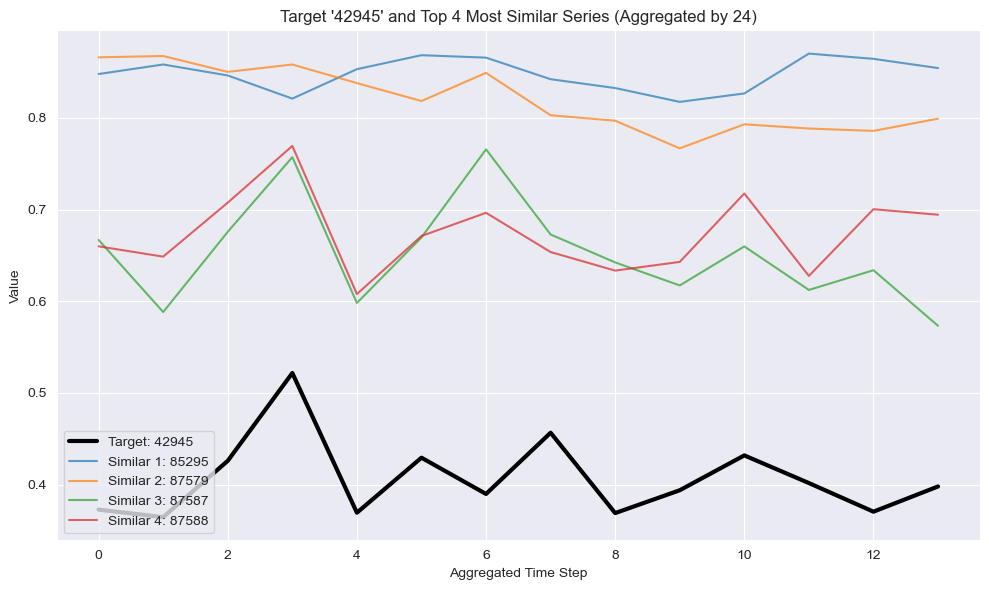

Stable cases: ['43823', '87581', '89449', '89450', '89453']


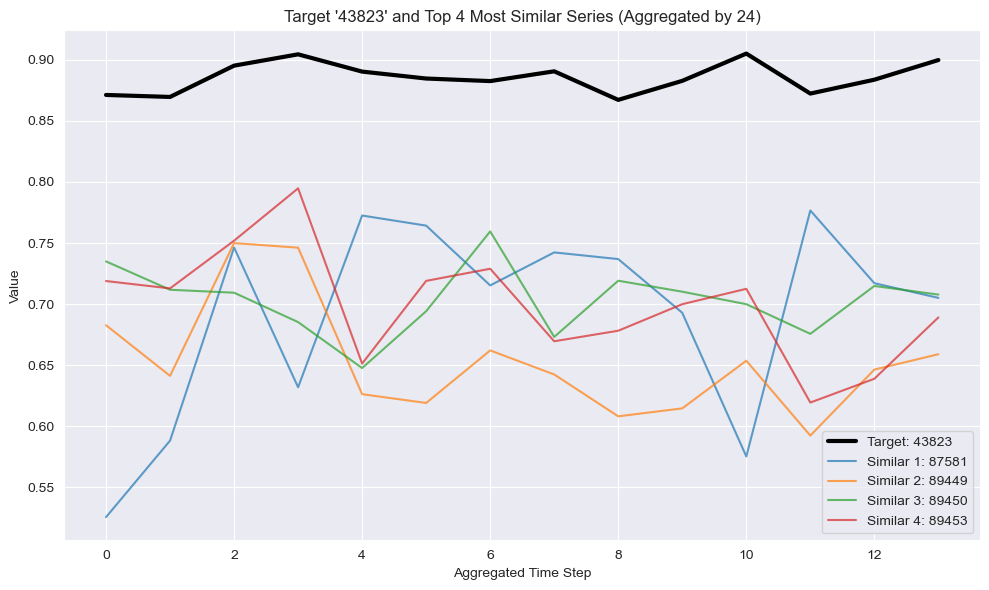

Stable cases: ['36284', '37402', '43821', '80134', '80459']


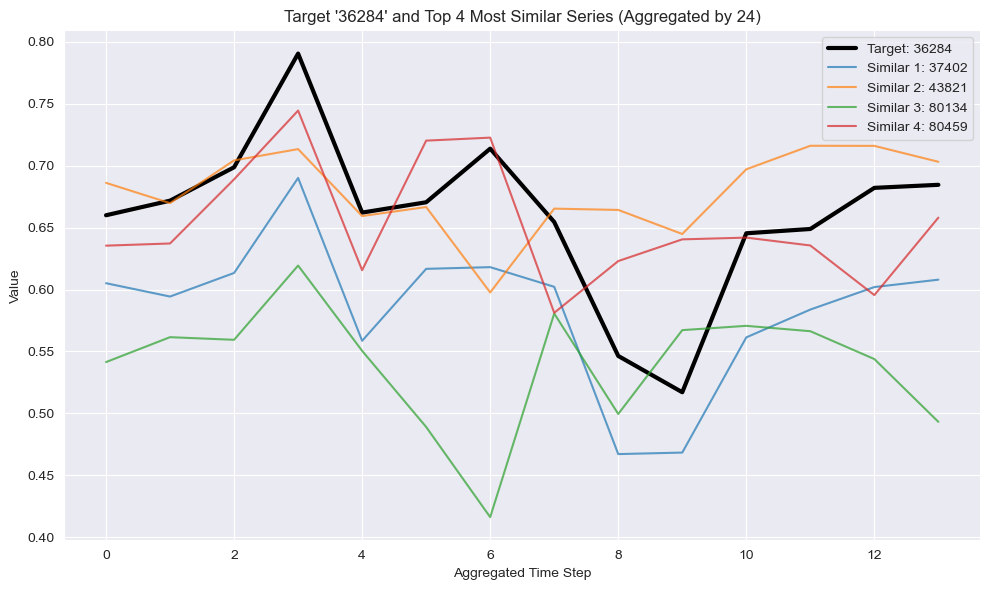

Stable cases: ['40575', '42149', '42760', '43976', '88842']


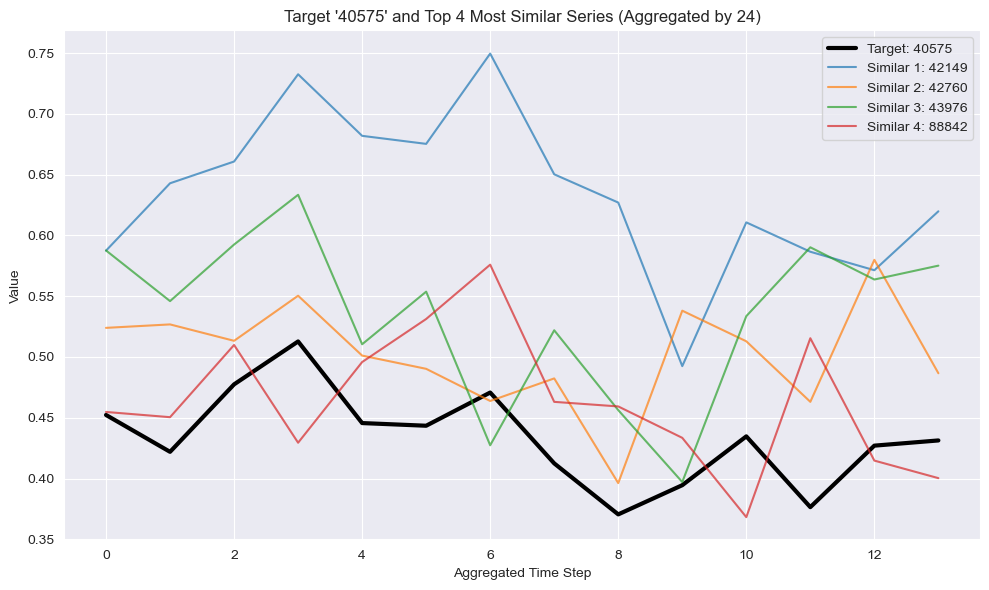

In [90]:
time_tgt = 1250000

stable = select_stable_cases(df = df_guan, timestamp=time_tgt, agg_window=24, threshold=0.12, method='std')
print("Stable cases:", stable)
plot_similar_columns(series_dict, target_col = stable[0], similar_cols = stable[1:], agg_factor = 24)

stable_2 = select_stable_cases(df = df_guan[[col for col in df_guan.columns if col not in stable]], timestamp=time_tgt, agg_window=24, threshold=0.15, method='std')
print("Stable cases:", stable_2)
plot_similar_columns(series_dict, target_col = stable_2[0], similar_cols = stable_2[1:], agg_factor = 24)

stable_3 = select_stable_cases(df = df_guan[[col for col in df_guan.columns if col not in (stable + stable_2)]], timestamp=time_tgt, agg_window=24, threshold=0.195, method='std')
print("Stable cases:", stable_3)
plot_similar_columns(series_dict, target_col = stable_3[0], similar_cols = stable_3[1:], agg_factor = 24)

stable_4 = select_stable_cases(df = df_guan[[col for col in df_guan.columns if col not in (stable + stable_2 + stable_3)]], timestamp=time_tgt, agg_window=24, threshold=0.2223, method='std')
print("Stable cases:", stable_4)
plot_similar_columns(series_dict, target_col = stable_4[0], similar_cols = stable_4[1:], agg_factor = 24)

Stable cases: ['38764', '42148', '43382', '43989', '80458', '80543', '85271']


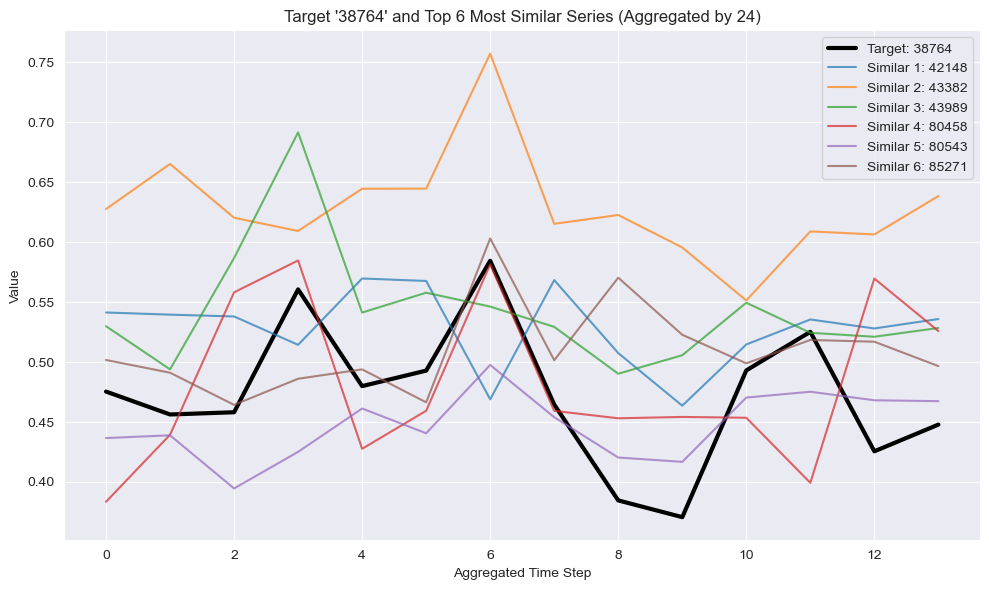

In [126]:
def select_unstable_cases_test(df, timestamp, agg_window=2, threshold=0.05, method='std'):
    """
    Select stable cases around a given timestamp.

    Args:
        df (pd.DataFrame): The full time series data.
        timestamp (float or int): Timestamp to center the window on.
        agg_window (int): Number of rows before and after to include.
        threshold (float): Maximum allowed variation (std or range).
        method (str): 'std' or 'range' for variation check.

    Returns:
        List of case IDs (columns) considered stable.
    """
    # Find closest index to the given timestamp
    idx = (df['timestamp'] - timestamp).abs().idxmin()

    # Define window bounds
    start_idx = max(0, idx - agg_window)
    end_idx = min(len(df), idx + agg_window + 1)

    # Subset the window
    window_df = df.iloc[start_idx:end_idx, 3:]  # skip non-case columns

    stable_cases = []

    for case in window_df.columns:
        values = window_df[case].dropna()

        if method == 'std':
            variation = np.std(values)
        elif method == 'range':
            variation = values.max() - values.min()
        else:
            raise ValueError("Method must be 'std' or 'range'")

        if variation >= threshold:
            stable_cases.append(case)

    return stable_cases

agg_fctor = 24
unstable = select_unstable_cases_test(df = df_guan[[col for col in df_guan.columns if col not in (stable + stable_2 + stable_3 + stable_4)]], timestamp=time_tgt, agg_window=agg_fctor, threshold=.85, method='range')
print("Stable cases:", unstable)
plot_similar_columns(series_dict, target_col = unstable[0], similar_cols = unstable[1:], agg_factor = agg_fctor)

Cases with largest mean drift: ['80458', '89451', '86229', '43989', '72022']


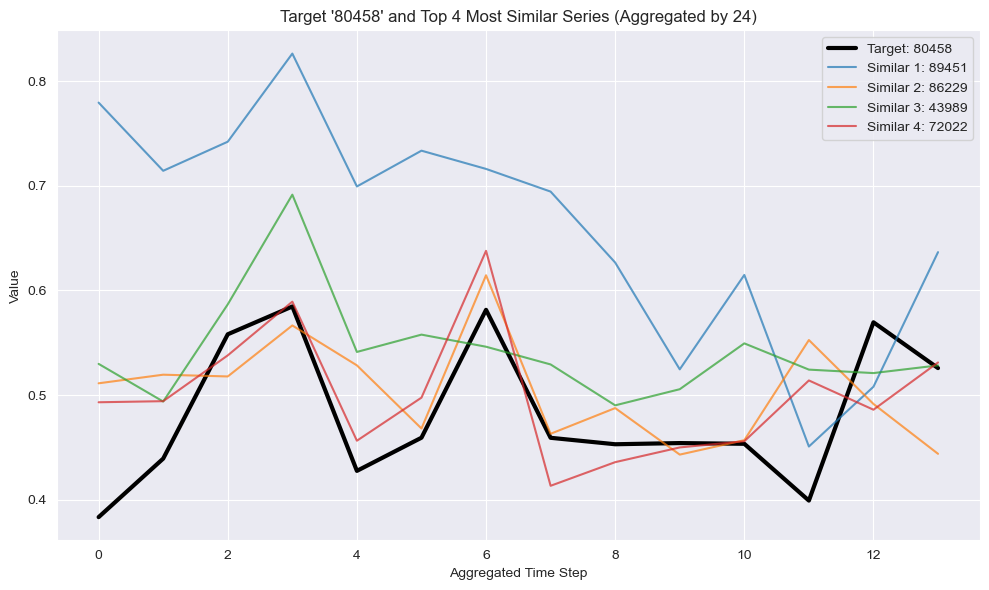

In [152]:
time_tgt_2 = 2000000
agg_factor = 24
# Detect cases with largest average shift over time
unstable_cases, mean_diffs = select_unstable_cases(
    df_guan[[col for col in df_guan.columns if col not in (stable + stable_2 + stable_3 + stable_4)]], timestamp=time_tgt_2, agg_window=agg_factor, top_n=5, method='mean_diff'
)

print("Cases with largest mean drift:", unstable_cases)

plot_similar_columns(series_dict, target_col = unstable_cases[0], similar_cols = unstable_cases[1:], agg_factor = agg_factor)

In [150]:
time_tgt_2 = 2000000
df_guan[df_guan['timestamp'] < time_tgt_2].shape, df_guan[df_guan['timestamp'] > time_tgt_2].shape

((6667, 36), (1685, 36))

C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
C:\Users\arthu\AppData\Local\Temp\ipykernel_12800\3765291205.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pivoted = pivoted.fillna(method='ffill').fillna(method='bfill')  # handle missing values
C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


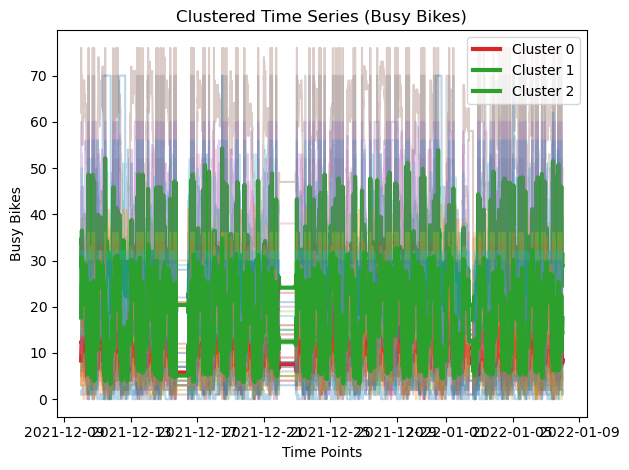

In [6]:
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



# Pivot the time series: one row per station (id), one column per timestamp
pivoted = combined_df.pivot(index='time', columns='id', values='busy')  # or 'free'/'total'
pivoted = pivoted.fillna(method='ffill').fillna(method='bfill')  # handle missing values
pivoted = pivoted.T  # now each row is a time serie

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivoted)

n_clusters = 3  # pick based on your data
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels back to the pivoted data
pivoted['cluster'] = labels

import matplotlib.pyplot as plt

# Plot cluster centroids
for cluster_id in range(n_clusters):
    series = pivoted[pivoted['cluster'] == cluster_id].drop('cluster', axis=1)
    plt.plot(series.T, alpha=0.3)  # all series in cluster
    plt.plot(series.mean(axis=0), label=f'Cluster {cluster_id}', linewidth=3)

plt.title('Clustered Time Series (Busy Bikes)')
plt.xlabel('Time Points')
plt.ylabel('Busy Bikes')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Reshape for tslearn: (n_samples, n_timestamps, 1)
X_ts = pivoted.drop('cluster', axis=1).values[:, :, None]
X_ts = TimeSeriesScalerMeanVariance().fit_transform(X_ts)

model = TimeSeriesKMeans(n_clusters=3, metric="dtw", random_state=0)
labels = model.fit_predict(X_ts)

MemoryError: Unable to allocate 532. MiB for an array with shape (8352, 8352) and data type float64

C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
C:\Users\arthu\AppData\Local\Temp\ipykernel_972\1252445231.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pivoted = pivoted.fillna(method='ffill').fillna(method='bfill')


Euclidean k-means
71.931 --> 43.736 --> 43.082 --> 43.082 --> 
DBA k-means (DTW)
Init 1


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


34.297 --> 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


...

23.923 --> 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


23.923 --> 


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s


Soft-DTW k-means
1329.394 --> 641.708 --> 601.065 --> 601.122 --> 601.108 --> 601.108 --> 601.107 --> 601.117 --> 601.104 --> 601.104 --> 601.101 --> 601.100 --> 601.099 --> 601.098 --> 601.097 --> 601.097 --> 601.097 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 601.096 --> 


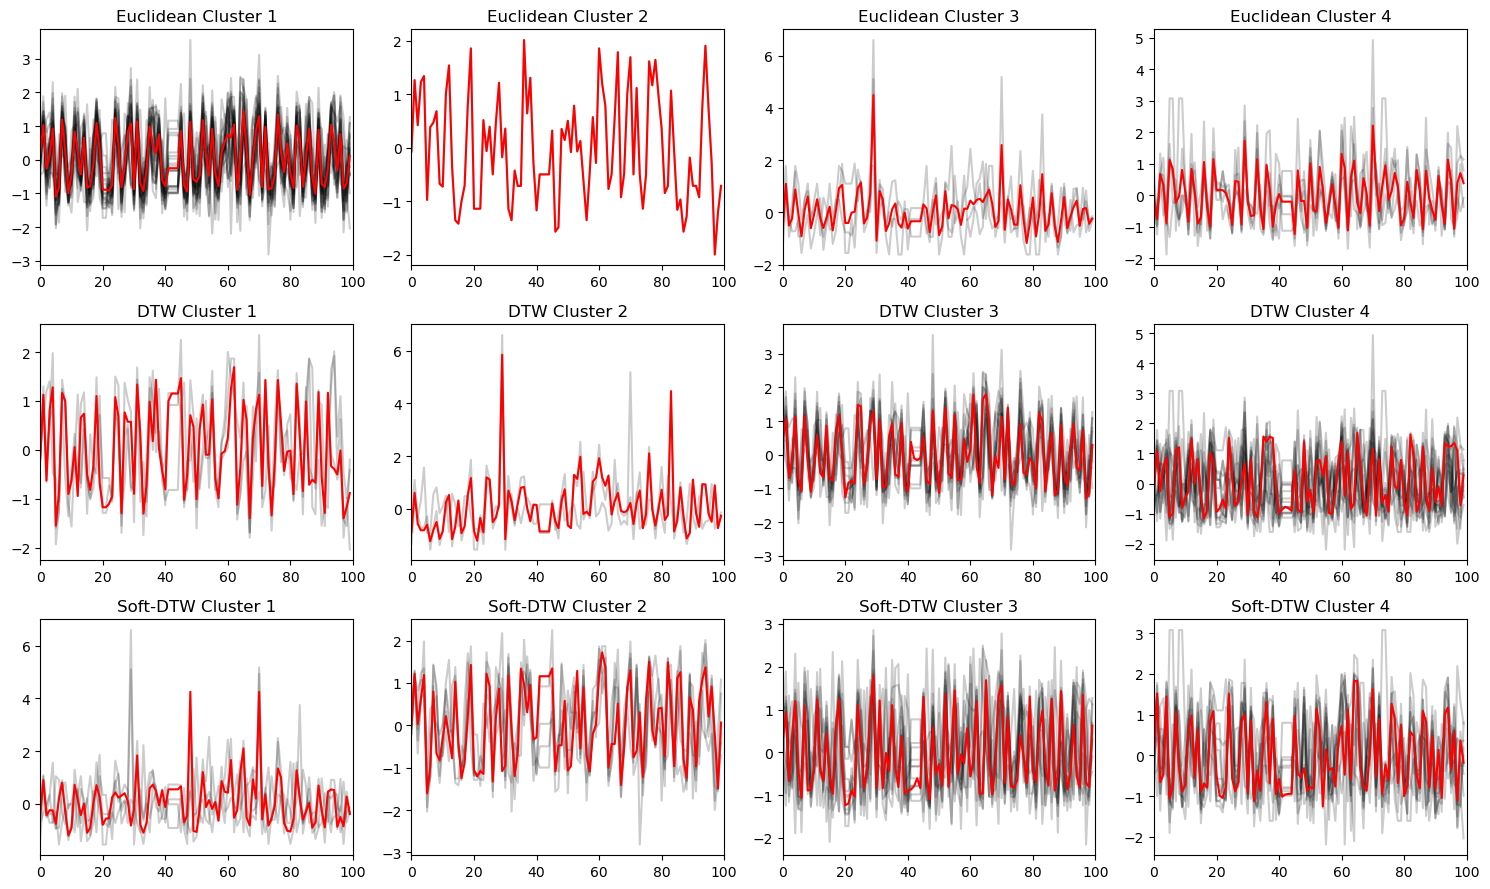

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler

# -----------------------------
# Step 1: Load your data
# -----------------------------
file_paths = glob.glob('data_leaks/benchmark/train_guan/*.xlsx')
dfs = []

for path in file_paths:
    df = pd.read_excel(path)
    df['id'] = os.path.splitext(os.path.basename(path))[0]
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_df['time'] = pd.to_datetime(combined_df['time'])

# -----------------------------
# Step 2: Pivot into (n_samples, n_timestamps)
# -----------------------------
# Choose 'busy' as the metric to cluster
pivoted = combined_df.pivot(index='time', columns='id', values='busy')
pivoted = pivoted.fillna(method='ffill').fillna(method='bfill')
pivoted = pivoted.T  # Each row is one time series

# -----------------------------
# Step 3: Convert to 3D array (n_samples, n_timestamps, 1)
# -----------------------------
X = pivoted.values[:, :, np.newaxis]  # Add dimension for tslearn

# Rescale
X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X)

# Optional: Resample to fixed length (e.g., 40 timestamps)
X_resampled = TimeSeriesResampler(sz=100).fit_transform(X_scaled)
sz = X_resampled.shape[1]

# -----------------------------
# Step 4: Clustering
# -----------------------------
seed = 0
n_clusters = 4

print("Euclidean k-means")
km = TimeSeriesKMeans(n_clusters=n_clusters, verbose=True, random_state=seed)
y_pred_euc = km.fit_predict(X_resampled)

print("DBA k-means (DTW)")
dba_km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", n_init=2,
                          verbose=True, max_iter_barycenter=10, random_state=seed)
y_pred_dba = dba_km.fit_predict(X_resampled)

print("Soft-DTW k-means")
sdtw_km = TimeSeriesKMeans(n_clusters=n_clusters, metric="softdtw",
                           metric_params={"gamma": .01}, verbose=True, random_state=seed)
y_pred_sdtw = sdtw_km.fit_predict(X_resampled)

# -----------------------------
# Step 5: Plot results
# -----------------------------
plt.figure(figsize=(15, 9))

for cluster_id in range(n_clusters):
    # Euclidean
    plt.subplot(3, n_clusters, cluster_id + 1)
    for ts in X_resampled[y_pred_euc == cluster_id]:
        plt.plot(ts.ravel(), "k-", alpha=0.2)
    plt.plot(km.cluster_centers_[cluster_id].ravel(), "r-")
    plt.title(f"Euclidean Cluster {cluster_id + 1}")
    plt.xlim(0, sz)

    # DBA (DTW)
    plt.subplot(3, n_clusters, n_clusters + cluster_id + 1)
    for ts in X_resampled[y_pred_dba == cluster_id]:
        plt.plot(ts.ravel(), "k-", alpha=0.2)
    plt.plot(dba_km.cluster_centers_[cluster_id].ravel(), "r-")
    plt.title(f"DTW Cluster {cluster_id + 1}")
    plt.xlim(0, sz)

    # Soft-DTW
    plt.subplot(3, n_clusters, 2 * n_clusters + cluster_id + 1)
    for ts in X_resampled[y_pred_sdtw == cluster_id]:
        plt.plot(ts.ravel(), "k-", alpha=0.2)
    plt.plot(sdtw_km.cluster_centers_[cluster_id].ravel(), "r-")
    plt.title(f"Soft-DTW Cluster {cluster_id + 1}")
    plt.xlim(0, sz)

plt.tight_layout()
plt.show()

In [17]:
df = combined_df.copy()
df['avaliable'] = df['free'] / df['total']
df['timestep'] = ((df['time'] - df['time'].min()).dt.total_seconds() // 300).astype(int)
df.head()

,time,station_id,total,free,busy,id,avaliable,timestep
0,2021-12-10 00:00:00,26323,24,4,20,26323,0.166667,0
1,2021-12-10 00:05:00,26323,24,4,20,26323,0.166667,1
2,2021-12-10 00:10:00,26323,24,4,20,26323,0.166667,2
3,2021-12-10 00:15:00,26323,24,4,20,26323,0.166667,3
4,2021-12-10 00:20:00,26323,24,4,20,26323,0.166667,4


In [35]:
qwe = df[df['timestep'] <= 5][['timestep', 'avaliable', 'station_id']]
t1 = qwe[(qwe['avaliable'] >= .80) & (qwe['avaliable'] < 1)]
t1.station_id.unique()

array([43382, 43823, 85295, 87579], dtype=int64)

In [37]:
t2 = qwe[(qwe['avaliable'] >= .15) & (qwe['avaliable'] < 0.40)]
t2.station_id.unique()

array([26323, 26898, 36284, 37402, 38764, 40575, 42148, 42149, 42945,
       43976, 43989, 72022, 72122, 80458, 80543, 86229, 87588, 88842],
      dtype=int64)

In [39]:
t3 = qwe[(qwe['avaliable'] >= .50) & (qwe['avaliable'] < 0.80)]
t3.station_id.unique()

array([26898, 36284, 38764, 40574, 42149, 42760, 43382, 43821, 43823,
       43989, 72122, 80134, 80458, 80459, 80543, 85271, 87581, 87587,
       87588], dtype=int64)

<Axes: xlabel='timestep', ylabel='avaliable'>

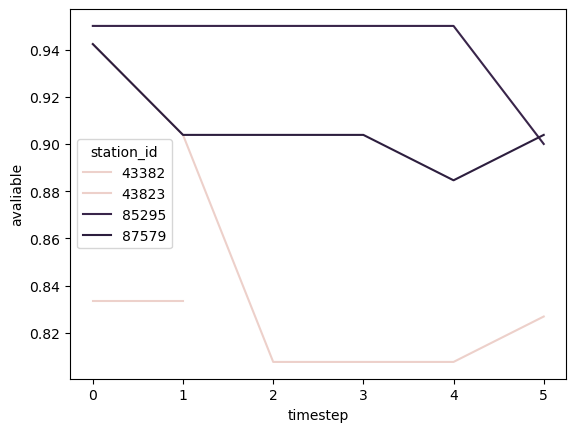

In [43]:
import seaborn as sns

sns.lineplot(data = t1,
            x = 'timestep',
            y = 'avaliable',
            hue = 'station_id')

In [16]:
import pandas as pd
import os
import glob

# Step 1: Load all Excel files
file_paths = glob.glob('data_leaks/benchmark/test_guan/*.xlsx')
station_dfs = []

for path in file_paths:
    df = pd.read_excel(path)

    # Convert time to datetime
    df['timestamp'] = pd.to_datetime(df['time'])

    # Get station_id (assume all rows in file have same value)
    station_id = df['station_id'].iloc[0]

    # Create a new column: available = free / total
    df[f'{station_id}'] = df['free'] / df['total']

    # Keep only relevant columns
    df = df[['timestamp', f'{station_id}']]

    # Set time as index
    # df = df.set_index('time')

    station_dfs.append(df)

# Step 2: Combine all into one DataFrame (time index, station_id columns)
df_guan = pd.concat(station_dfs, axis=1)

# Step 3: (Optional) Create timestep column based on 5-min intervals
df_guan = df_guan.sort_index()
# df_guan['timestep'] = ((df_guan.index - df_guan.index.min()).total_seconds() // 300).astype(int)
df_guan = df_guan.loc[:, ~df_guan.columns.duplicated()]

# Done!
df_guan.head()

,timestamp,89086,89449,89450,89451,89453
0,2021-12-10 00:00:00,0.60,0.7,0.869565,0.551724,0.550
1,2021-12-10 00:05:00,0.48,0.8,0.804348,0.482759,0.550
2,2021-12-10 00:10:00,0.44,0.8,0.804348,0.517241,0.525
3,2021-12-10 00:15:00,0.40,0.7,0.739130,0.448276,0.525
4,2021-12-10 00:20:00,0.40,0.6,0.717391,0.413793,0.500


In [8]:
for client in df_guan.columns:
    print(client)

89086
89449
89450
89451
89453
timestep


In [13]:
df_guan[[client]]

,timestep
time,
2021-12-10 00:00:00,0
2021-12-10 00:05:00,1
2021-12-10 00:10:00,2
2021-12-10 00:15:00,3
2021-12-10 00:20:00,4
...,...
2022-01-07 23:35:00,8347
2022-01-07 23:40:00,8348
2022-01-07 23:45:00,8349


<Axes: xlabel='time', ylabel='avaliable'>

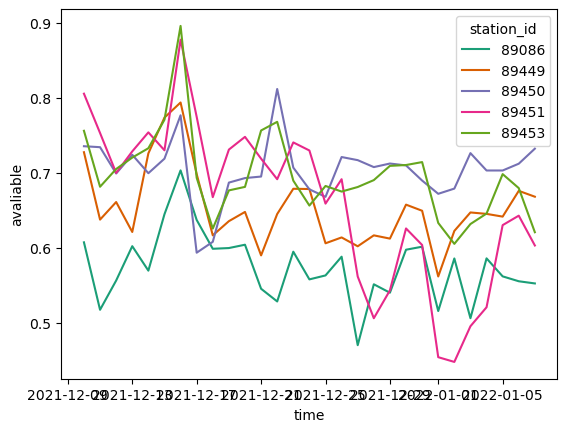

In [125]:
df_plot = df_guan.groupby('station_id').resample('24h')['avaliable'].mean().reset_index()
# df_plot = df_plot[df_plot['timestep'] > 7000]
sns.lineplot(data = df_plot,#[df_plot['station_id'].isin([89450, 89453, 89449])],
            x = 'time',
            y = 'avaliable',
            hue = 'station_id',
            palette = 'Dark2',
            )

In [24]:
import pandas as pd
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

# Sample setup
df['Available'] = df['free'].astype(float) / df['total'].astype(float)

# Ensure Available is a flat float array
df['Available'] = df['Available'].astype(float)

# Parameters
window_size = 12
windows = []

# Break the series into fixed-size windows
for i in range(0, len(df) - window_size + 1, window_size):
    window_data = df.iloc[i:i+window_size]['Available'].to_numpy().flatten()
    if window_data.ndim != 1:
        raise ValueError(f"Window {i} is not 1D: shape {window_data.shape}")
    windows.append((i, i+window_size, window_data))

In [ ]:
from fastdtw import fastdtw

# Define a scalar distance function
scalar_distance = lambda a, b: abs(a - b)

# DTW loop
min_distance = float('inf')
pair = (None, None)

for i in range(len(windows)):
    for j in range(i + 1, len(windows)):
        x = windows[i][2]
        y = windows[j][2]
        dist, _ = fastdtw(x, y, dist=scalar_distance)
        if dist < min_distance:
            min_distance = dist
            pair = (i, j)

print("Most similar pair of windows:", pair)


In [ ]:
import numpy as np

# Average of the two similar series
first_series_avg = (windows[first_pair_indices[0]][2] + windows[first_pair_indices[1]][2]) / 2

# Find another window (farther in time) that is similar
min_drift_distance = float('inf')
drift_candidate = None

for k in range(len(windows)):
    if k not in first_pair_indices:
        dist, _ = fastdtw(windows[k][2], first_series_avg, dist=euclidean)
        if dist < min_drift_distance:
            min_drift_distance = dist
            drift_candidate = k

print("Drift candidate window:", drift_candidate)


In [2]:
import pandas as pd
import os
import glob
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from sklearn.metrics.pairwise import cosine_distances

def client_self_cosine_drift(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    for client_id, group in data_latent.groupby('client_id'):
        group_sorted = group.sort_values('label')  # Ensure chronological order
        vectors = group_sorted[features].values
        labels = group_sorted['label'].values

        if len(vectors) < 2:
            continue  # Skip clients with only one label

        # First and last vectors
        first_vector = vectors[0].reshape(1, -1)
        last_vector = vectors[-1].reshape(1, -1)

        # # 1. Distance of last label to all previous labels
        # for i in range(len(vectors) - 1):
        #     res = {
        #         'client_id': client_id,
        #         'label': labels[i],
        #         'compared_to': labels[-1],
        #         'drift_type': 'last_vs_earlier',
        #         'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), last_vector)[0][0],
        #     }
        #     results.append(res)

        # 2. Distance of first label to all later labels
        for i in range(1, len(vectors)):
            res = {
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[0],
                'drift_type': 'first_vs_later',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), first_vector)[0][0],
            }
            results.append(res)

        # 3. Rolling (Consecutive)
        for i in range(len(vectors) - 1):
            results.append({
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[i + 1],
                'drift_type': 'rolling',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), vectors[i + 1].reshape(1, -1))[0][0],
            })

    return pd.DataFrame(results)

def plot_cosine_drift(df_drift):
    # Filter labels <11 or >13
    df_plot = df_drift[(df_drift['label'] < 11) | (df_drift['label'] > 12)].copy()

    # Create new column for FacetGrid row
    df_plot['label_range'] = df_plot['label'].apply(lambda x: '<11' if x < 11 else '>13')

    # Plot using seaborn FacetGrid
    g = sns.FacetGrid(
        df_plot,
        row='label_range',
        col='drift_type',
        hue='client_id',
        margin_titles=True,
        sharey=False,
        sharex=True,
        height=3,
        aspect=1
    )

    g.map_dataframe(sns.lineplot, x='label', y='cosine_distance')

    g.add_legend()
    g.set_axis_labels("Label", "Cosine Distance")
    g.set_titles(col_template="{col_name}", row_template="Label {row_name}")
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle("Client Self-Cosine Drift Over Labels", fontsize=16)

    plt.show()

In [4]:
def rank_clients_by_drift(df):
    # 1. Filter out unwanted labels
    df = df[~df['label'].isin([11, 12])].copy()

    # 2. Define the periods
    periods = {
        'first_4_months': list(range(0, 4)),
        'all_periods': sorted(df['label'].unique())  # already excludes 11, 12
    }

    # 3. Store results in a dictionary
    ranked_results = {}

    for period_name, valid_labels in periods.items():
        df_period = df[df['label'].isin(valid_labels)].copy()

        # === a) Per-label RANKING ===
        df_period['rank'] = df_period.groupby(['drift_type', 'label'])['cosine_distance']\
                                     .rank(method='dense', ascending=False)

        # === b) Summary STATS (mean and sum per client) ===
        agg_stats = df_period.groupby(['drift_type', 'client_id'])['cosine_distance']\
                             .agg(['mean', 'sum'])\
                             .rename(columns={'mean': 'mean_distance', 'sum': 'sum_distance'})\
                             .reset_index()

        # === c) Rank clients by mean and sum ===
        agg_stats['rank_by_mean'] = agg_stats.groupby('drift_type')['mean_distance']\
                                             .rank(method='dense', ascending=False)

        agg_stats['rank_by_sum'] = agg_stats.groupby('drift_type')['sum_distance']\
                                            .rank(method='dense', ascending=False)

        # Store both the detailed and summary DataFrames
        ranked_results[period_name] = {
            'detailed': df_period,
            'summary': agg_stats
        }

    return ranked_results


from collections import defaultdict
import os

def analyze_experiments_by_epoch(data, epochs = None, top_n=2):
    results = {}

    for experiment in data:
        results[experiment] = {}

        data_path = os.path.join(experiment, 'Baseline_latent_space.parquet')
        new_latent = pd.read_parquet(data_path)

        experiment_summary_rows = []

        epochs_loop = epochs if epochs is not None else new_latent['epoch'].sort_values().unique()
        for epoch in epochs_loop:
            data_epoch = new_latent[
                (new_latent['epoch'].astype(str) == str(epoch)) &
                (new_latent['client_id'].str.contains('_proto'))
            ]

            if data_epoch.empty:
                print(f'    ⚠ No data for epoch {epoch}, skipping...')
                continue

            df_drift = client_self_cosine_drift(data_epoch)
            ranked = rank_clients_by_drift(df_drift)

            compiled_summaries = {}

            for period_name, result in ranked.items():
                summary = result['summary'].copy()

                summary['experiment'] = experiment
                summary['epoch'] = epoch
                summary['period'] = period_name

                # Rank delta
                summary['rank_diff'] = (summary['rank_by_mean'] - summary['rank_by_sum']).abs()

                # Collect for experiment-level summary
                experiment_summary_rows.append(summary)

                # Top-N for both rank types
                top_by_mean = summary.sort_values(['drift_type', 'rank_by_mean']).groupby('drift_type').head(top_n)
                top_by_mean['rank_type'] = 'mean'

                top_by_sum = summary.sort_values(['drift_type', 'rank_by_sum']).groupby('drift_type').head(top_n)
                top_by_sum['rank_type'] = 'sum'

                compiled = pd.concat([top_by_mean, top_by_sum], ignore_index=True)
                compiled.sort_values(by=['drift_type', 'rank_type'], inplace=True)

                compiled_summaries[period_name] = compiled

            results[experiment][epoch] = {
                'ranked': ranked,
                'compiled_summary': compiled_summaries
            }

        # 🔄 Per-Experiment Global Analysis
        if experiment_summary_rows:
            exp_df = pd.concat(experiment_summary_rows, ignore_index=True)

            # === 1. Average Ranks + Rank Delta ===
            avg_ranks = exp_df.groupby(['client_id', 'drift_type'])[
                ['rank_by_mean', 'rank_by_sum', 'rank_diff']
            ].mean().reset_index()
            avg_ranks.rename(columns={
                'rank_by_mean': 'avg_rank_by_mean',
                'rank_by_sum': 'avg_rank_by_sum',
                'rank_diff': 'avg_rank_delta'
            }, inplace=True)

            # === 2. Stability Index (Top-N appearances) ===
            stability_counts = defaultdict(lambda: {'mean': 0, 'sum': 0})
            for _, row in exp_df.iterrows():
                if row['rank_by_mean'] <= top_n:
                    stability_counts[(row['client_id'], row['drift_type'])]['mean'] += 1
                if row['rank_by_sum'] <= top_n:
                    stability_counts[(row['client_id'], row['drift_type'])]['sum'] += 1

            stability_df = pd.DataFrame([
                {
                    'client_id': cid,
                    'drift_type': drift_type,
                    'stability_topN_mean': counts['mean'],
                    'stability_topN_sum': counts['sum']
                }
                for (cid, drift_type), counts in stability_counts.items()
            ])

            # === 3. Combine metrics
            experiment_metrics = avg_ranks.merge(stability_df, on=['client_id', 'drift_type'], how='outer')
            results[experiment]['summary_metrics'] = experiment_metrics
            results[experiment]['all_summary_df'] = exp_df

        else:
            results[experiment]['summary_metrics'] = pd.DataFrame()
            results[experiment]['all_summary_df'] = pd.DataFrame()

    return results



In [55]:
import pandas as pd

def extract_best_clients_by_summary_metrics(results_dict):
    """
    Extract the top client (lowest avg_rank_by_mean) per drift_type for each experiment,
    based on the summary_metrics table.

    Parameters:
        results_dict (dict): Structure like:
            results[experiment]['summary_metrics']

    Returns:
        pd.DataFrame: DataFrame with top clients per drift_type per experiment,
                      plus drift detection diagnostics.
    """
    top_clients_all_experiments = []

    for experiment_name, experiment_data in results_dict.items():
        summary_metrics = experiment_data.get('summary_metrics')

        if summary_metrics is None or summary_metrics.empty:
            continue

        # For each drift_type, get the client with the lowest avg_rank_by_mean
        top_clients_df = (
            summary_metrics
            .sort_values(['drift_type', 'avg_rank_by_mean'])
            .groupby('drift_type')
            .head(1)
            .copy()
        )

        top_clients_df['experiment'] = experiment_name

        # Retain only necessary columns
        top_clients_all_experiments.append(top_clients_df[['client_id', 'drift_type', 'experiment']])

    # Combine all experiments into one DataFrame
    summary_df = pd.concat(top_clients_all_experiments, ignore_index=True)

    # Add derived/diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] = 'D' #summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df


def extract_best_clients_by_ranked_summary_initial(results_dict):
    """
    For each experiment, extract clients that most frequently rank highest (rank_by_mean == 1)
    across epochs, per drift_type.

    Parameters:
        results_dict (dict): Nested structure:
            results[experiment][epoch]['ranked']['first_4_months']['summary']

    Returns:
        pd.DataFrame: DataFrame with top clients per drift_type per experiment, plus diagnostics.
    """
    top_clients_all_experiments = []

    for experiment_name, experiment_data in results_dict.items():
        top_rows_per_epoch = []

        for epoch in range(10):
            epoch_key = str(epoch)
            if epoch_key not in experiment_data:
                continue

            summary_df = experiment_data[epoch_key]['ranked']['first_4_months']['summary']
            if summary_df.empty:
                continue

            top_rank_df = summary_df[summary_df['rank_by_mean'] == 1].copy()
            top_rank_df['epoch'] = epoch
            top_rows_per_epoch.append(top_rank_df)

        # Skip experiment if no qualifying rows
        if not top_rows_per_epoch:
            continue

        # Combine across epochs
        combined_epoch_df = pd.concat(top_rows_per_epoch, ignore_index=True)

        # Count appearances of each client at rank 1 per drift_type
        client_rank_counts = (
            combined_epoch_df.groupby(['drift_type', 'client_id'])
            .size()
            .reset_index(name='count')
        )

        # Select clients with the highest count per drift_type
        max_counts_per_drift = client_rank_counts.groupby('drift_type')['count'].transform('max')
        top_clients_df = client_rank_counts[client_rank_counts['count'] == max_counts_per_drift].copy()
        top_clients_df['experiment'] = experiment_name

        top_clients_all_experiments.append(top_clients_df[['client_id', 'drift_type', 'experiment']])

    # Combine results from all experiments
    summary_df = pd.concat(top_clients_all_experiments, ignore_index=True)

    # Add diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] = 'D' #summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df



def extract_best_clients_by_max_cosine_distance(results_dict):
    """
    For each experiment and epoch, identify clients with the maximum cosine_distance
    per drift_type, and count which clients appear most often across epochs.

    Parameters:
        results_dict (dict): Nested results dictionary with structure:
            results[experiment][epoch]['ranked']['first_4_months']['detailed']

    Returns:
        pd.DataFrame: Summary DataFrame with top clients per drift_type per experiment,
                      and additional columns for analysis.
    """
    best_clients_all_experiments = []

    for experiment_name, experiment_data in results_dict.items():
        max_cosine_rows_per_epoch = []

        for epoch in range(10):
            detailed_df = experiment_data[str(epoch)]['ranked']['first_4_months']['detailed']

            # Keep only rank 1 entries
            rank_1_df = detailed_df[detailed_df['rank'] == 1]

            # For each drift_type, select the row with max cosine_distance
            max_cosine_df = rank_1_df.loc[
                rank_1_df.groupby('drift_type')['cosine_distance'].idxmax()
            ].copy()

            max_cosine_df['epoch'] = epoch
            max_cosine_rows_per_epoch.append(max_cosine_df)

        # Combine epochs for this experiment
        combined_epochs_df = pd.concat(max_cosine_rows_per_epoch)

        # Count how many times each client appears as top cosine_distance per drift_type
        client_counts = (
            combined_epochs_df.groupby(['drift_type', 'client_id'])
            .size()
            .reset_index(name='count')
        )

        # Keep only clients with the highest count per drift_type
        max_count_per_drift = client_counts.groupby('drift_type')['count'].transform('max')
        top_clients = client_counts[client_counts['count'] == max_count_per_drift].copy()
        top_clients['experiment'] = experiment_name

        best_clients_all_experiments.append(top_clients[['client_id', 'drift_type', 'experiment']])

    # Combine across all experiments
    summary_df = pd.concat(best_clients_all_experiments, ignore_index=True)

    # Add derived/diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] = 'D' #summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_extraction_methods(setup_dict, results, extractors):
    """
    Evaluate multiple extraction methods on different experiment setups,
    return a DataFrame with normalized accuracy results, and plot them.

    Parameters:
        setup_dict (dict): Mapping from setup name to list of experiment names.
        results (dict): Main results dictionary.
        extractors (list of tuples): List of (label, extraction_function).

    Returns:
        pd.DataFrame: Combined summary of correct/wrong % per drift_type, setup, and method.
    """
    all_ct_results = []

    for setup_name, experiment_list in setup_dict.items():
        experiment_subset = {exp: results[exp] for exp in experiment_list}

        for label, extract_func in extractors:
            print(f'{setup_name} - {label.upper()}')
            summary_df = extract_func(experiment_subset)

            # Crosstab: % correct and wrong per drift_type
            crosstab = (
                pd.crosstab(summary_df['drift_type'], summary_df['check'], normalize='index') * 100
            ).round(2)

            crosstab.rename(columns={True: 'correct_%', False: 'wrong_%'}, inplace=True)
            crosstab['drift_type'] = crosstab.index
            crosstab['setup'] = setup_name
            crosstab['method'] = label
            all_ct_results.append(crosstab.reset_index(drop=True))

    # Combine into single DataFrame
    ct_summary_df = pd.concat(all_ct_results, ignore_index=True)

    return ct_summary_df, summary_df

In [56]:
import random
from collections import defaultdict

import random
from collections import defaultdict

def balanced_sample_per_class(folder_experiment, n_per_class):
    # 1. Group entries by class (A_, B_, C_, D_, E_)
    class_groups = defaultdict(list)
    for item in folder_experiment:
        filename = item.split('\\')[-1]  # get just the file part
        prefix = filename[:2]  # expects A_, B_, etc.
        if prefix in ['A_', 'B_', 'C_', 'D_', 'E_']:
            class_groups[prefix].append(item)

    # 2. Sample n items per class (if enough data is available)
    result = []
    for cls, items in class_groups.items():
        if len(items) < n_per_class:
            raise ValueError(f"Not enough items in class {cls}: needed {n_per_class}, found {len(items)}")
        result.extend(random.sample(items, n_per_class))

    return result



folders_experiment = [f for f in glob.glob(os.path.join('results', '*BENCHMARK_INITIA*')) if os.path.isdir(f)]

sampled = balanced_sample_per_class(folders_experiment, 1)
for s in sampled:
    print(s)


results = analyze_experiments_by_epoch(data = folders_experiment, epochs = None)

import pickle

with open('results/imgs/experiment_benchmark_analysis.pkl', 'wb') as f:
    pickle.dump(results, f)

_24_1_3600 - MAX COSINE
_24_1_3600 - RANK COSINE
_24_1_3600 - SUMMARY
_6_1_1800 - MAX COSINE
_6_1_1800 - RANK COSINE
_6_1_1800 - SUMMARY
_12_1_3600 - MAX COSINE
_12_1_3600 - RANK COSINE
_12_1_3600 - SUMMARY
_12_1_1800 - MAX COSINE
_12_1_1800 - RANK COSINE
_12_1_1800 - SUMMARY
_24_1_1800 - MAX COSINE
_24_1_1800 - RANK COSINE
_24_1_1800 - SUMMARY
_6_1_3600 - MAX COSINE
_6_1_3600 - RANK COSINE
_6_1_3600 - SUMMARY


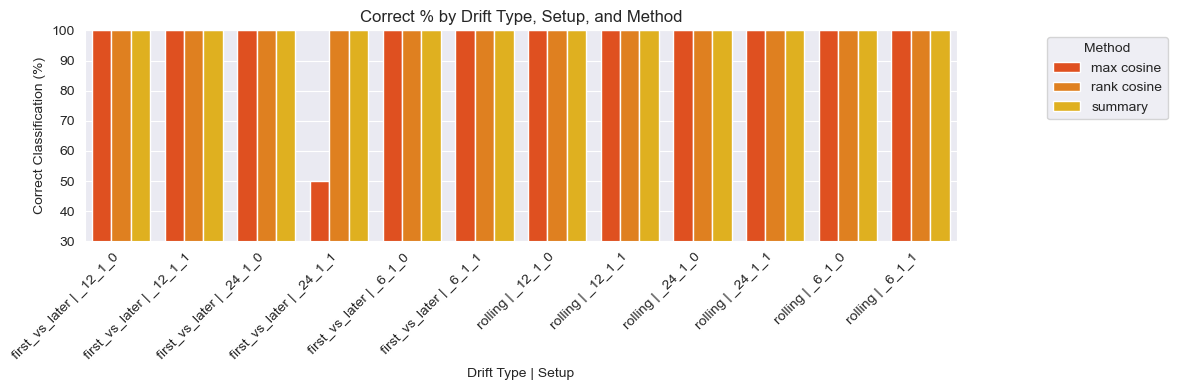

In [57]:
possible_exps = set([exp.split('__')[-2] for exp in list(results.keys())])

setup_dict = {}
for setup in possible_exps:
    exps_setup = [exp for exp in list(results.keys()) if setup in exp]
    setup_dict[setup] = exps_setup

extraction_methods = [
    ("max cosine", extract_best_clients_by_max_cosine_distance),
    ("rank cosine", extract_best_clients_by_ranked_summary_initial),
    ("summary", extract_best_clients_by_summary_metrics)
]

results_evaluation, summary_df = evaluate_extraction_methods(setup_dict, results, extraction_methods)

import seaborn as sns
import matplotlib.pyplot as plt

# Create a combined category for drift_type and setup
results_evaluation['setup'] = results_evaluation['setup'].apply(
    lambda s: '_'.join(s.split('_')[:-1] + [str(int(int(s.split('_')[-1]) / 3600))])
)

results_evaluation['drift+setup'] = results_evaluation['drift_type'] + " | " + results_evaluation['setup']

plt.figure(figsize=(12, 4))
sns.barplot(
    data=results_evaluation,
    x='drift+setup',
    y='correct_%',
    hue='method',
    order = results_evaluation['drift+setup'].sort_values().unique(),
    palette='autumn'
)
plt.xticks(rotation=45, ha='right')
plt.ylim((30, 100))
plt.ylabel('Correct Classification (%)')
plt.xlabel('Drift Type | Setup')
plt.title('Correct % by Drift Type, Setup, and Method')
plt.legend(title='Method', bbox_to_anchor = (1.25,1))
plt.tight_layout()
plt.show()

In [58]:
summary_df

,client_id,drift_type,experiment,client_drift,ground_truth,check
0,District_D__proto,first_vs_later,results\Benchmark_10_2_1_6_BENCHMARK_INITIAL__...,D,D,True
1,District_D__proto,rolling,results\Benchmark_10_2_1_6_BENCHMARK_INITIAL__...,D,D,True
2,District_D__proto,first_vs_later,results\Benchmark_10_5_1_6_BENCHMARK_INITIAL__...,D,D,True
3,District_D__proto,rolling,results\Benchmark_10_5_1_6_BENCHMARK_INITIAL__...,D,D,True


In [49]:
results['results\\Benchmark_10_5_1_24_BENCHMARK_INITIAL___24_1_3600___0']['1']['ranked']['first_4_months']['detailed']

,client_id,label,compared_to,drift_type,cosine_distance,rank
0,District_A__proto,1,0,first_vs_later,0.003584,3.0
1,District_A__proto,2,0,first_vs_later,0.095419,2.0
2,District_A__proto,3,0,first_vs_later,0.261167,1.0
4,District_A__proto,0,1,rolling,0.003584,3.0
5,District_A__proto,1,2,rolling,0.101146,2.0
6,District_A__proto,2,3,rolling,0.048605,1.0
7,District_A__proto,3,4,rolling,0.000147,4.0
8,District_B__proto,1,0,first_vs_later,0.005539,2.0
9,District_B__proto,2,0,first_vs_later,0.087219,4.0
10,District_B__proto,3,0,first_vs_later,0.224572,3.0


In [43]:
import warnings
warnings.filterwarnings('ignore')

for experiment in sampled:

    print(f'\n\nEXPERIMENT {experiment}:')

    data_path = experiment + '\Baseline_latent_space.parquet'
    new_latent = pd.read_parquet(data_path)
    data_epoch = new_latent[(new_latent['epoch'] == '8') & (new_latent['client_id'].str.contains('_proto'))]

    df_drift = client_self_cosine_drift(data_epoch)

    plot_cosine_drift(df_drift)

In [50]:
results_evaluation

check,wrong_%,drift_type,setup,method,drift+setup
0,100.0,first_vs_later,_24_1_1,max cosine,first_vs_later | _24_1_1
1,100.0,rolling,_24_1_1,max cosine,rolling | _24_1_1
2,100.0,first_vs_later,_24_1_1,rank cosine,first_vs_later | _24_1_1
3,100.0,rolling,_24_1_1,rank cosine,rolling | _24_1_1
4,100.0,first_vs_later,_24_1_1,summary,first_vs_later | _24_1_1
5,100.0,rolling,_24_1_1,summary,rolling | _24_1_1
6,100.0,first_vs_later,_6_1_0,max cosine,first_vs_later | _6_1_0
7,100.0,rolling,_6_1_0,max cosine,rolling | _6_1_0
8,100.0,first_vs_later,_6_1_0,rank cosine,first_vs_later | _6_1_0
9,100.0,rolling,_6_1_0,rank cosine,rolling | _6_1_0
